# Issue

So the things is that we've reach too high performance using SBM generator without learning, only using an encoder, a generated graph, and a inner product

In [91]:
from networkx.generators.community import stochastic_block_model
import networkx as nx
import matplotlib.pyplot as plt
import torch
import pandas as pd
import time
import random
from tqdm import tqdm
import torch.nn as nn
import seaborn as sns
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx, to_networkx, to_undirected
from torch_geometric.nn import GCNConv
from torch_sparse import SparseTensor
from ogb.linkproppred import Evaluator
from torch_geometric.transforms import RandomLinkSplit

In [75]:
hp = {'hidden': 256}

In [99]:
nb_nodes = 20
nb_block = 5
sizes = [nb_nodes for _ in range(nb_block)]
probs = [[0.3, 0.0001, 0.0005, 0.0002, 0.0004],
        [0.0001, 0.8, 0.0001, 0.0006, 0.0002],
        [0.0005, 0.0001, 0.65, 0.0001, 0.0003],
        [0.0002, 0.0006, 0.0001, 0.1, 0.0001],
        [0.0004, 0.0002, 0.0003, 0.0001, 0.4]]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
evaluator = Evaluator(name='ogbl-ppa')

Data(edge_index=[2, 860], block=[100], partition=[5], name='stochastic_block_model', num_nodes=100)


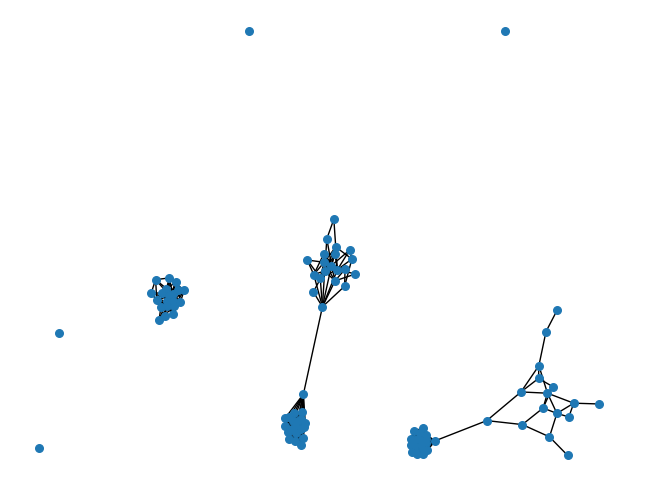

In [100]:
def gen_sbm(sizes, probs, device=None, seed=random.randint(1, 10000)):
    G = stochastic_block_model(sizes, probs, seed=seed)
    nx.draw(G, node_size=30)
    data = from_networkx(G)
    print(data)
    data.num_nodes = sum(sizes)
    data.sizes = sizes
    data.probs = probs
    data.num_features = data.num_nodes
    data.x = F.one_hot(torch.arange(0, sum(sizes))).float()
    if device is not None:
        data = data.to(device)
    return data
data = gen_sbm(sizes, probs, device=device, seed=0)

In [85]:
def randomsplit(dataset, val_ratio: float = 0.10, test_ratio: float = 0.2):
    def removerepeated(ei):
        ei = to_undirected(ei)

        ei = ei[:, ei[0] < ei[1]]
        return ei
    def split_pos_neg(data):
        pos_mask = (data.edge_label == 1).bool()
        neg_mask = (data.edge_label == 0).bool()
        pos_edge_index = data.edge_label_index[:, pos_mask]
        neg_edge_index = data.edge_label_index[:, neg_mask]
        return pos_edge_index, neg_edge_index

    data = dataset[0]
    data.num_nodes = data.x.shape[0]
    transform = RandomLinkSplit(
        num_val=val_ratio,
        num_test=test_ratio,
        is_undirected=True,
        add_negative_train_samples=True
    )
    train_data, val_data, test_data = transform(data)
    val_data_pos, val_data_neg = split_pos_neg(val_data)
    test_data_pos, test_data_neg = split_pos_neg(test_data)
    
    split_edge = {'train': {'edge': train_data.edge_index.t()},
                  'valid': {'edge': val_data_pos.t(),
                            'edge_neg': val_data_neg.t()}, 
                  'test': {'edge': test_data_pos.t(),
                           'edge_neg': test_data_neg.t()}}
    data.edge_index = to_undirected(split_edge["train"]["edge"].t())
    data.adj_t = SparseTensor.from_edge_index(data.edge_index, sparse_sizes=(data.num_nodes, data.num_nodes))
    data.adj_t = data.adj_t.to_symmetric().coalesce()
    return split_edge
split_edge = randomsplit([data])
print("dataset split ")
for key1 in split_edge:
    for key2  in split_edge[key1]:
        print(key1, key2, split_edge[key1][key2].shape[0])

dataset split 
train edge 602
valid edge 43
valid edge_neg 43
test edge 86
test edge_neg 86


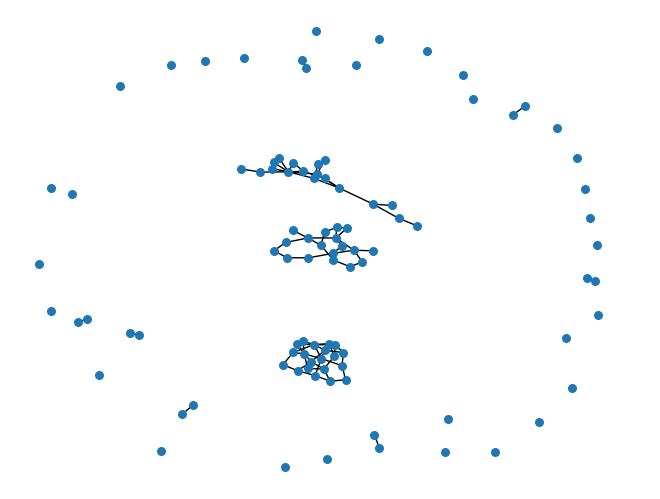

In [97]:
graph_test_pos = Data(data.x, to_undirected(split_edge['test']['edge'].t()))
Gtp = to_networkx(graph_test_pos, to_undirected=True)
nx.draw(Gtp, node_size=30)

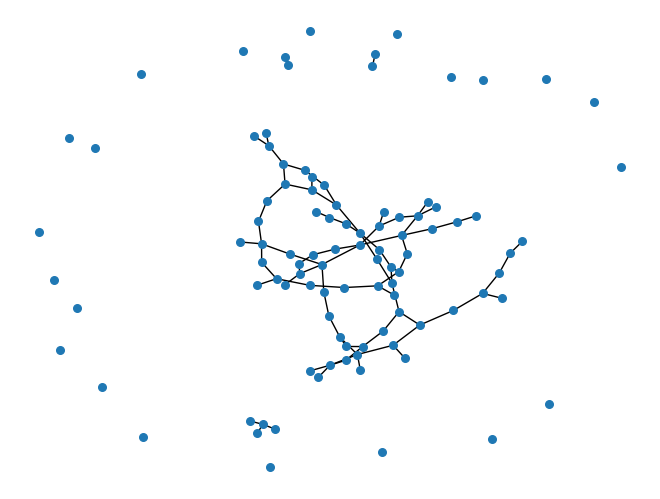

In [96]:
graph_test_neg = Data(data.x, to_undirected(split_edge['test']['edge_neg'].t()))
Gtn = to_networkx(graph_test_neg, to_undirected=True)
nx.draw(Gtn, node_size=30)

In [86]:
class grace_encoder(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, activation=nn.Identity(), base_model=GCNConv, k: int = 2):
        super(grace_encoder, self).__init__()
        self.base_model = base_model
        self.out_channels = out_channels

        assert k >= 2
        self.k = k
        self.conv = [base_model(in_channels, 2 * out_channels)]
        for _ in range(1, k - 1):
            self.conv.append(base_model(2 * out_channels, 2 * out_channels))
        self.conv.append(base_model(2 * out_channels, out_channels))
        self.conv = nn.ModuleList(self.conv)
        self.activation = activation

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        for i in range(self.k):
            x = self.activation(self.conv[i](x, edge_index))
        return x
encoder = grace_encoder(data.num_features, hp['hidden']).to(device)

In [87]:
class inner_prod(torch.nn.Module):

    def __init__(self):
        super().__init__()

    def multidomainforward(self, x, adj, tar_ei, filled=False, cndroppprobs = []):
        x_i = x[tar_ei[0]]
        x_j = x[tar_ei[1]]
        x = x_i * x_j
        out = torch.sum(x, dim=-1)
        return out

    def forward(self, x, adj, tar_ei, filled1=False):
        return self.multidomainforward(x, adj, tar_ei)
predictor = inner_prod()

In [88]:
def visu_tsne(h):
    tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
    h = h.cpu()
    tsne_results = tsne.fit_transform(h)
    df = pd.DataFrame()    
    df['tsne-2d-one'] = tsne_results[:,0]
    df['tsne-2d-two'] = tsne_results[:,1]
    display(df)
    
    plt.figure(figsize=(16,10))
    sns.scatterplot(
        x="tsne-2d-one", y="tsne-2d-two",
        palette=sns.color_palette("hls", 10),
        data=df,
        legend="full",
        alpha=0.3
    )

[t-SNE] Computing 99 nearest neighbors...
[t-SNE] Indexed 100 samples in 0.001s...
[t-SNE] Computed neighbors for 100 samples in 0.006s...
[t-SNE] Computed conditional probabilities for sample 100 / 100
[t-SNE] Mean sigma: 0.215839
[t-SNE] KL divergence after 250 iterations with early exaggeration: 47.037666
[t-SNE] KL divergence after 300 iterations: 0.201823


/home/jovyan/envs/p312/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


,tsne-2d-one,tsne-2d-two
0,2.218014,-1.066388
1,4.507034,-1.214276
2,3.732357,0.748652
3,1.939652,-0.074164
4,2.667155,2.808115
...,...,...
95,-0.160129,4.492112
96,0.229959,3.520210
97,-1.181043,4.117911
98,-0.598744,4.193874


/tmp/ipykernel_56781/95212592.py:11: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


tensor([ 0.0508,  0.0583,  0.0437,  0.0575,  0.0648,  0.0796,  0.0509,  0.0618,
         0.0622,  0.0525,  0.0616,  0.0636,  0.0598,  0.0483,  0.0496,  0.0856,
         0.0222,  0.0591,  0.0612,  0.0506,  0.0385,  0.0626,  0.0623,  0.0170,
         0.0555,  0.0583, -0.0120,  0.0158,  0.0295,  0.0544,  0.0538,  0.0607,
        -0.0324,  0.0160,  0.0635,  0.0571,  0.0706,  0.0271,  0.0674,  0.0559,
         0.0185,  0.0427,  0.0304,  0.0598,  0.0193,  0.0465,  0.0396,  0.0444,
         0.0676,  0.0549,  0.0569,  0.0546,  0.0135,  0.0642,  0.0493,  0.0525,
         0.0676,  0.0524,  0.0500,  0.0344,  0.0601,  0.0490,  0.0493,  0.0614,
         0.0254,  0.0464,  0.0727,  0.0447,  0.0489,  0.0232,  0.0571,  0.0535,
         0.0197,  0.0237,  0.0301,  0.0207,  0.0689,  0.1064,  0.0603,  0.0572,
         0.0396,  0.0790,  0.0447,  0.0578,  0.0579,  0.0674]) tensor([ 2.4182e-02,  1.2763e-02,  7.1183e-03, -3.3217e-05,  3.5944e-05,
         6.8901e-03, -8.3511e-03, -5.1882e-03,  5.0332e-03,  3.2

{'Hits@10': (0.9534883720930233, 0.9651162790697675),
 'Hits@20': (0.9767441860465116, 0.9767441860465116),
 'Hits@50': (1.0, 0.9767441860465116),
 'Hits@100': (1.0, 1.0),
 'ROCAUC': (np.float64(0.9345592212006489), np.float64(0.9407787993510004))}

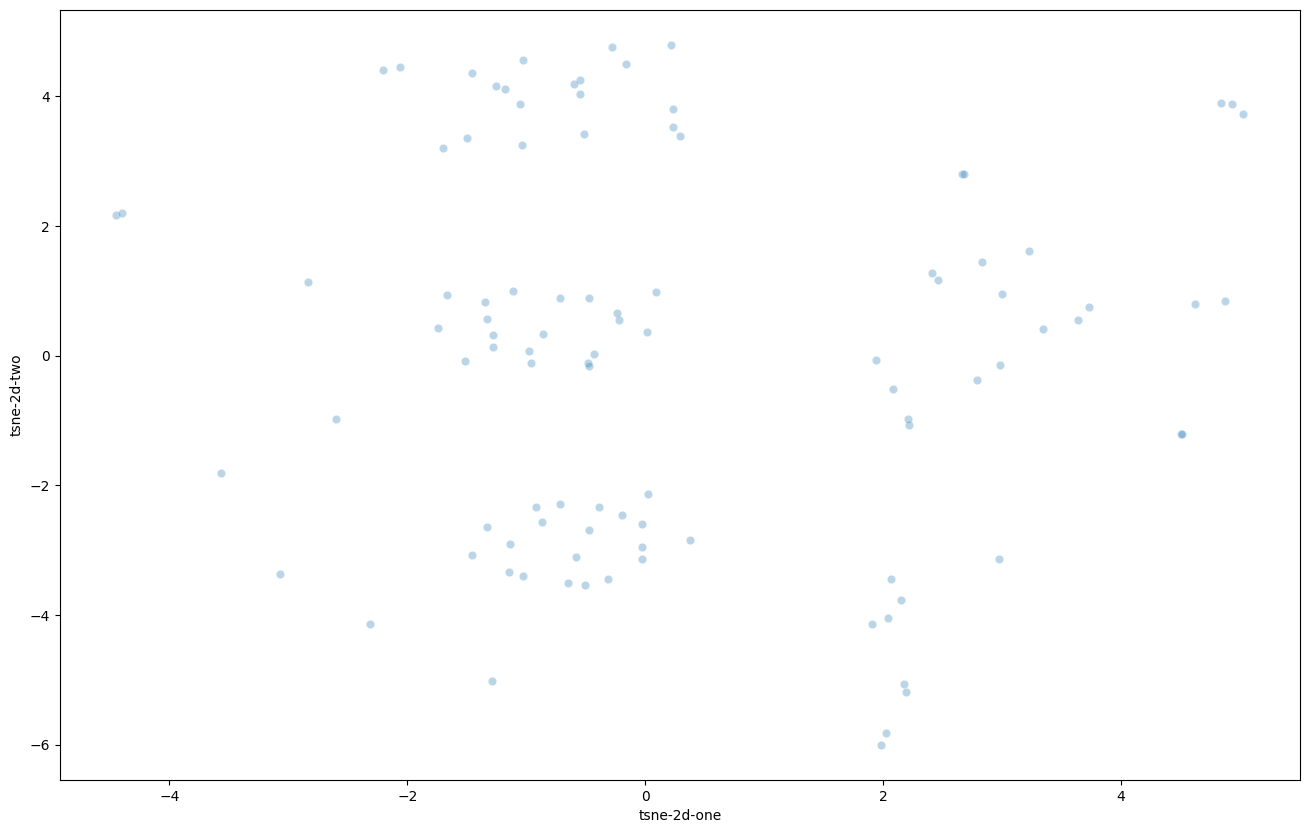

In [89]:
@torch.no_grad()
def test(encoder: nn.Module, predictor: nn.Module, data, split_edge: dict, evaluator: Evaluator, batch_size: int,
         use_valedges_as_input, res_dict: dict):
    # adapted from MPLP code
    encoder.eval()
    predictor.eval()
    device = data.adj_t.device()
    adj_t = data.adj_t
    h = encoder(data.x, adj_t)
    visu_tsne(h)

    def test_split(split):
        # pred positive edges and negatives edges for nodes in the split
        pos_test_edge = split_edge[split]['edge'].to(device)
        neg_test_edge = split_edge[split]['edge_neg'].to(device)
        pos_test_preds = []
        test_edge = torch.hstack((pos_test_edge, neg_test_edge))
        for perm in DataLoader(range(pos_test_edge.size(0)), batch_size):
            edge = pos_test_edge[perm].t()
            out = predictor(h, adj_t, edge)
            pos_test_preds += [out.squeeze().cpu()]
        pos_test_pred = torch.cat(pos_test_preds, dim=0)
        neg_test_preds = []
        for perm in DataLoader(range(neg_test_edge.size(0)), batch_size):
            edge = neg_test_edge[perm].t()
            out = predictor(h, adj_t, edge)
            neg_test_preds += [out.squeeze().cpu()]
        neg_test_pred = torch.cat(neg_test_preds, dim=0)

        return pos_test_pred, neg_test_pred

    pos_valid_pred, neg_valid_pred = test_split('valid')
    if use_valedges_as_input:
        adj_t = data.full_adj_t
        h = encoder(data.x, adj_t)
    pos_test_pred, neg_test_pred = test_split('test')
    print(pos_test_pred, neg_test_pred)
    results = {}
    evaluator.eval_metric = 'hits@k'
    for K in [10, 20, 50, 100]:
        evaluator.K = K
        valid_hits = evaluator.eval({
            'y_pred_pos': pos_valid_pred,
            'y_pred_neg': neg_valid_pred,
        })[f'hits@{K}']
        test_hits = evaluator.eval({
            'y_pred_pos': pos_test_pred,
            'y_pred_neg': neg_test_pred,
        })[f'hits@{K}']
        results[f'Hits@{K}'] = (valid_hits, test_hits)
    pos_valid_pred = pos_valid_pred[:neg_valid_pred.shape[0]]
    pos_test_pred = pos_test_pred[:neg_test_pred.shape[0]]
    evaluator.eval_metric = 'rocauc'
    valid_auc = evaluator.eval({
        'y_pred_pos': pos_valid_pred,
        'y_pred_neg': neg_valid_pred,
    })['rocauc']
    test_auc = evaluator.eval({
        'y_pred_pos': pos_test_pred,
        'y_pred_neg': neg_test_pred,
    })['rocauc']
    results['ROCAUC'] = (valid_auc, test_auc)
    return results
res_dict = {"Hits@10": [], "Hits@20": [], "Hits@50": [], "Hits@100": [], 'ROCAUC': [], 'pretrain_time': []}
test(encoder, predictor, data, split_edge, evaluator, 512, False, res_dict)